In [2]:
import matplotlib.pyplot as plt
import cv2

def mosaic(img, rect, size):
    # 모자이크 적용할 부분 추출하기
    (x1, y1, x2, y2) = rect
    w = x2 - x1
    h = y2 - y1
    i_rect = img[y1:y2, x1:x2]
    # 축소하고 확대하기
    i_small = cv2.resize(i_rect, ( size, size))
    i_mos = cv2.resize(i_small, (w, h), interpolation=cv2.INTER_AREA)
    # 모자이크 적용하기
    img2 = img.copy()
    img2[y1:y2, x1:x2] = i_mos
    return img2

얼굴의 좌표 = 146 35 162 162


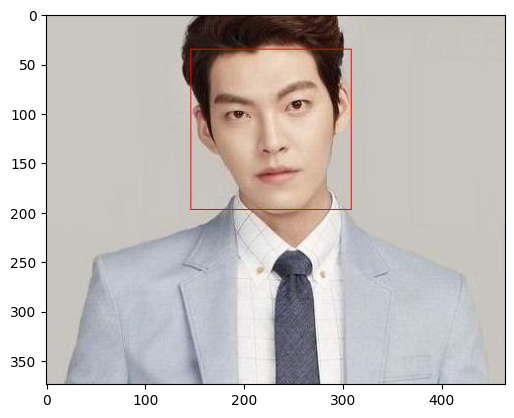

In [4]:
im_read1="Kimwoobin.jpg"

# 캐스케이드 파일 지정해서 검출기 생성하기 
cascade_file = "haarcascade_frontalface_alt.xml"
cascade = cv2.CascadeClassifier(cascade_file)

# 이미지를 읽어 들이고 그레이스케일로 변환하기 
img = cv2.imread(im_read1)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 얼굴 검출하기
face_list = cascade.detectMultiScale(img_gray )

for (x,y,w,h) in face_list:
    print("얼굴의 좌표 =", x, y, w, h)
    red = (0, 0, 255)
    cv2.rectangle(img, (x, y), (x+w, y+h), red, thickness=1)

# 이미지 출력하기
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()



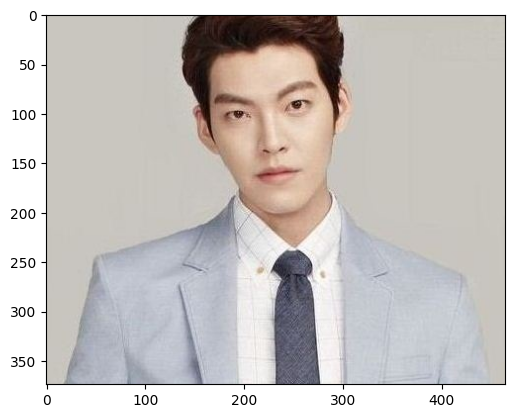

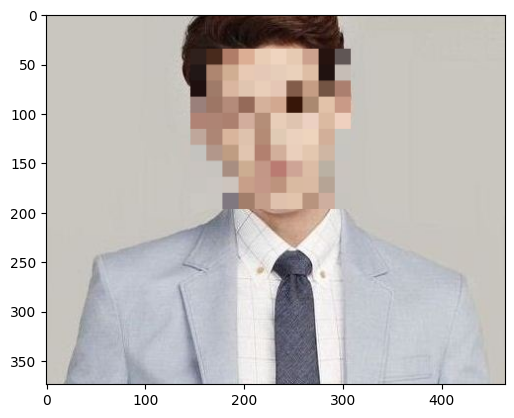

In [5]:
# 이미지를 읽어 들이고 그레이스케일로 변환하기
img = cv2.imread(im_read1)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 얼굴 검출하기
face_list = cascade.detectMultiScale(img_gray )

# 이미지 출력하기
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

# 검출한 부분에 모자이크 처리하기 
for (x,y,w,h) in face_list:
    img = mosaic(img, (x, y, x+w, y+h), 10)

# 이미지 출력하기
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [8]:
# 사진파일로 저장하기(좌측 [파일] 부분에서 마우스 우클릭 후 [새로고침]하면 생성된 [mosaic.jpg 파일]이 보입니다)

cv2.imwrite("mosaic.jpg", img)

True